# Fase 6 — Entrenamiento y visualización

**Objetivo:** entrenar el modelo completo y validar que converge.

Con datos sintéticos el SSIM será bajo (~0.02). Este notebook está diseñado para reutilizarse con datos reales en Fase 8 — solo cambia el dataset.

**Checks:**
1. Curvas de loss train vs val por época
2. SSIM y MAE en validación
3. Comparación visual: GAF target vs predicción del modelo
4. Diagonal: valores reales vs predichos

## 0. Setup

In [14]:
import sys
import os
sys.path.append('/app')

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

gpus = tf.config.list_physical_devices('GPU')
print('GPUs disponibles:', gpus)
assert len(gpus) > 0, '❌ No se detectó GPU'
print('✅ GPU OK')

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU OK


In [15]:
from config import (
    BATCH_SIZE, EPOCHS_PHASE1, EPOCHS_PHASE2,
    LR_PHASE1, LR_PHASE2, EARLY_STOPPING_PATIENCE,
    LOSS_MSE_WEIGHT, LOSS_SSIM_WEIGHT,
    NUM_LOCALES, NUM_PRODUCTOS,
    N_COMBOS_PER_EPOCH, N_COMBOS_PER_EPOCH_VAL,
    CHECKPOINTS, VISUALIZATIONS,
)
from model.autoencoder import build_autoencoder
from training.train import (
    train, make_synthetic_dataset, make_real_datasets,
    combined_loss, ssim_metric, mae_diagonal_metric,
)

os.makedirs(VISUALIZATIONS, exist_ok=True)
print('Config cargada ✅')


Config cargada ✅


## 1. Entrenamiento

Cambia `USE_SYNTHETIC = False` cuando tengas datos reales (Fase 8).

In [16]:
import pandas as pd
from data.loader import load_and_prepare, COL_FECHA

USE_SYNTHETIC = True   # ← cambiar a False en Fase 8
SMOKE_TEST    = True   # ← True para 2 épocas, False para entrenamiento completo

if USE_SYNTHETIC:
    print('⚠️  Usando datos sintéticos — SSIM esperado bajo (~0.02)')
    print('   Reemplaza con USE_SYNTHETIC=False en Fase 8')
    # make_synthetic_dataset genera dicts {'gaf_input', 'local_idx', 'producto_idx'}
    # El smoke test de train() los crea internamente también.
    # Solo necesitamos df_full etc. como placeholders para llamar train():
    train_df, val_df, test_df, local_map, product_map, valid_combos = load_and_prepare()
    df_full   = pd.concat([train_df, val_df, test_df])
    train_end = train_df[COL_FECHA].max()
    val_end   = val_df[COL_FECHA].max()
    # En smoke test, train() detecta smoke_test=True y usa make_synthetic_dataset internamente
else:
    # Fase 8: datos reales
    print('Cargando datos reales...')
    train_df, val_df, test_df, local_map, product_map, valid_combos = load_and_prepare()
    df_full   = pd.concat([train_df, val_df, test_df])
    train_end = train_df[COL_FECHA].max()
    val_end   = val_df[COL_FECHA].max()
    print(f'train_end: {train_end.date()}  val_end: {val_end.date()}')
    print(f'Combinaciones válidas: {len(valid_combos):,}')

print('✅ Datos listos')


⚠️  Usando datos sintéticos — SSIM esperado bajo (~0.02)
   Reemplaza con USE_SYNTHETIC=False en Fase 8
Cargando datos...
  Raw: 6,062,390 filas
Imputando...
  Después de imputación: 6,015,333 filas
Split temporal...
  Train: 4,138,281 filas | 2024-03-11 → 2025-08-07
  Val:   930,250 filas | 2025-08-08 → 2025-11-25
  Test:  946,802 filas | 2025-11-26 → 2026-03-15
Construyendo mappings...
  Locales:   1029
  Productos: 179
Filtrando combinaciones válidas...
  Combinaciones con >= 104 días: 12,358
✅ Datos listos


In [17]:
%%time
# train() construye los datasets internamente por época (re-sampleo)
# smoke_test=True → 2 épocas + datos sintéticos
# smoke_test=False → EPOCHS_PHASE1/PHASE2 con datos reales
histories = train(
    df_full, local_map, product_map, valid_combos,
    train_end, val_end,
    smoke_test=SMOKE_TEST,
)
print('\n✅ Entrenamiento completado')



⚠️  SMOKE TEST — datos sintéticos | sin checkpoints | sin logs

════════════════════════════════════════════════════════════
  FASE 1 — Encoder congelado
  LR=0.001  |  Épocas=2
════════════════════════════════════════════════════════════
8/8 [==============================] - 15s 432ms/step - loss: 0.6383 - ssim_metric: 0.0257 - mae_diagonal_metric: 0.6621 - val_loss: 0.6342 - val_ssim_metric: 0.0286 - val_mae_diagonal_metric: 0.6552
Época 1/2 — loss:0.6383 val_loss:0.6342 SSIM:0.0257 val_SSIM:0.0286
  ✅ Nuevo mejor Loss val: 0.6342 (smoke — no se guarda)
8/8 [==============================] - 1s 78ms/step - loss: 0.6127 - ssim_metric: 0.0279 - mae_diagonal_metric: 0.6176 - val_loss: 0.6146 - val_ssim_metric: 0.0273 - val_mae_diagonal_metric: 0.6116
Época 2/2 — loss:0.6127 val_loss:0.6146 SSIM:0.0279 val_SSIM:0.0273
  ✅ Nuevo mejor Loss val: 0.6146 (smoke — no se guarda)

  Loss validación Fase 1 (mejor): 0.6146 | SSIM validación Fase 1: 0.0273

══════════════════════════════════════

## 2. Curvas de entrenamiento

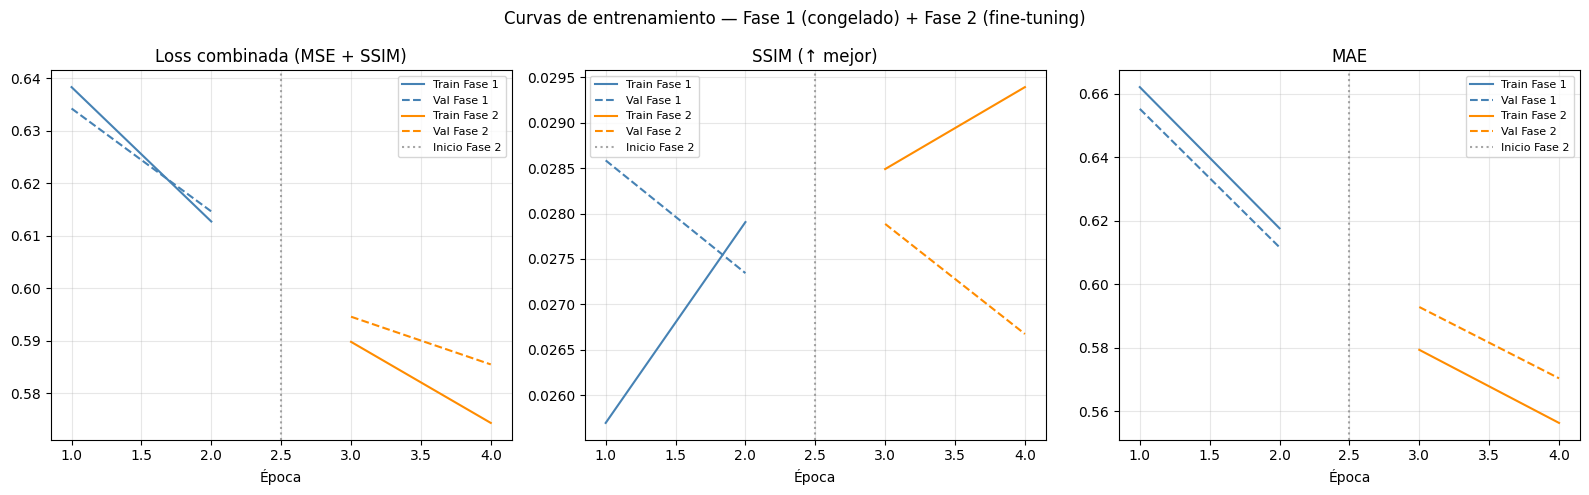

Guardado en /app/outputs/visualizations/fase6_training_curves.png


In [18]:
def plot_training_curves(histories: dict) -> None:
    h1 = histories['phase1']
    h2 = histories['phase2']

    # Concatenar fases
    epochs1 = len(h1['loss'])
    epochs2 = len(h2['loss'])
    total   = epochs1 + epochs2
    x1 = np.arange(1, epochs1 + 1)
    x2 = np.arange(epochs1 + 1, total + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Curvas de entrenamiento — Fase 1 (congelado) + Fase 2 (fine-tuning)', fontsize=12)

    metrics = [
        ('loss',        'val_loss',        'Loss combinada (MSE + SSIM)'),
        ('ssim_metric', 'val_ssim_metric', 'SSIM (↑ mejor)'),
        ('mae_diagonal_metric',  'val_mae_diagonal_metric',  'MAE'),
    ]

    for ax, (train_key, val_key, title) in zip(axes, metrics):
        # Fase 1
        ax.plot(x1, h1[train_key],  color='steelblue',  label='Train Fase 1')
        ax.plot(x1, h1[val_key],    color='steelblue',  label='Val Fase 1',   linestyle='--')
        # Fase 2
        ax.plot(x2, h2[train_key],  color='darkorange', label='Train Fase 2')
        ax.plot(x2, h2[val_key],    color='darkorange', label='Val Fase 2',   linestyle='--')
        # Separador entre fases
        ax.axvline(x=epochs1 + 0.5, color='gray', linestyle=':', alpha=0.7, label='Inicio Fase 2')
        ax.set_title(title)
        ax.set_xlabel('Época')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_training_curves.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')

plot_training_curves(histories)

In [19]:
# Resumen numérico
h1 = histories['phase1']
h2 = histories['phase2']

best_ssim_f1 = max(h1.get('val_ssim_metric', [0]))
best_ssim_f2 = max(h2.get('val_ssim_metric', [0]))
best_mae_f1  = min(h1.get('val_mae_diagonal_metric',  [1]))
best_mae_f2  = min(h2.get('val_mae_diagonal_metric',  [1]))

print('══════════════════════════════════════')
print('  Métricas de validación (mejor época)')
print('══════════════════════════════════════')
print(f'  SSIM Fase 1 : {best_ssim_f1:.4f}')
print(f'  SSIM Fase 2 : {best_ssim_f2:.4f}')
print(f'  MAE  Fase 1 : {best_mae_f1:.4f}')
print(f'  MAE  Fase 2 : {best_mae_f2:.4f}')
print('══════════════════════════════════════')

if not USE_SYNTHETIC:
    if best_ssim_f1 >= 0.7:
        print('  ✅ Objetivo SSIM Fase 1 > 0.7 alcanzado')
    else:
        print('  ⚠️  SSIM Fase 1 < 0.7 — considera más épocas')

══════════════════════════════════════
  Métricas de validación (mejor época)
══════════════════════════════════════
  SSIM Fase 1 : 0.0286
  SSIM Fase 2 : 0.0279
  MAE  Fase 1 : 0.6116
  MAE  Fase 2 : 0.5704
══════════════════════════════════════


## 3. Visualización: GAF target vs predicción

In [20]:
# Reconstruir modelo y cargar mejores pesos
autoencoder, encoder, decoder, emb_model = build_autoencoder(encoder_trainable=False)
autoencoder.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=[ssim_metric, mae_diagonal_metric],
)

# Construir val_ds para visualización (100 combinaciones, sin shuffle)
# train() no expone el val_ds final — lo reconstruimos aquí una vez
if USE_SYNTHETIC:
    val_ds = make_synthetic_dataset(n_samples=128, batch_size=BATCH_SIZE)
else:
    from dataset.tf_dataset import build_tf_dataset_sampled
    val_ds = build_tf_dataset_sampled(
        df_full, local_map, product_map, valid_combos,
        split='val',
        train_end_date=train_end,
        val_end_date=val_end,
        batch_size=BATCH_SIZE,
        shuffle=False,
        n_combos=N_COMBOS_PER_EPOCH_VAL,
    )

# Forward pass mínimo para inicializar variables antes de cargar pesos
dummy_inputs, _ = next(iter(val_ds))
autoencoder.predict(dummy_inputs, verbose=0)

best_weights = str(CHECKPOINTS / 'phase1_best.weights.h5')
if os.path.exists(best_weights):
    autoencoder.load_weights(best_weights, skip_mismatch=True)
    print(f'✅ Pesos cargados desde {best_weights}')
else:
    print('⚠️  No se encontraron pesos guardados — usando pesos actuales')


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:457: UserWarning: Could not load weights in object <keras.src.mixed_precision.loss_scale_optimizer.LossScaleOptimizerV3 object at 0x7fdddd15b090>. Skipping object. Exception encountered: 'LossScaleOptimizerV3' object has no attribute 'name'
  _load_state(


✅ Pesos cargados desde /app/outputs/checkpoints/phase1_best.weights.h5


In [21]:
# Tomar un batch de validación para visualizar
sample_inputs, sample_targets = next(iter(val_ds))

gaf_in   = sample_inputs['gaf_input'].numpy()
local_i  = sample_inputs['local_idx'].numpy()
prod_i   = sample_inputs['producto_idx'].numpy()
targets  = sample_targets.numpy()

predictions = autoencoder.predict(
    {'gaf_input': gaf_in, 'local_idx': local_i, 'producto_idx': prod_i},
    verbose=0,
)

print(f'Input shape      : {gaf_in.shape}')
print(f'Target shape     : {targets.shape}')
print(f'Prediction shape : {predictions.shape}')

Input shape      : (32, 90, 90, 3)
Target shape     : (32, 14, 14, 3)
Prediction shape : (32, 14, 14, 3)


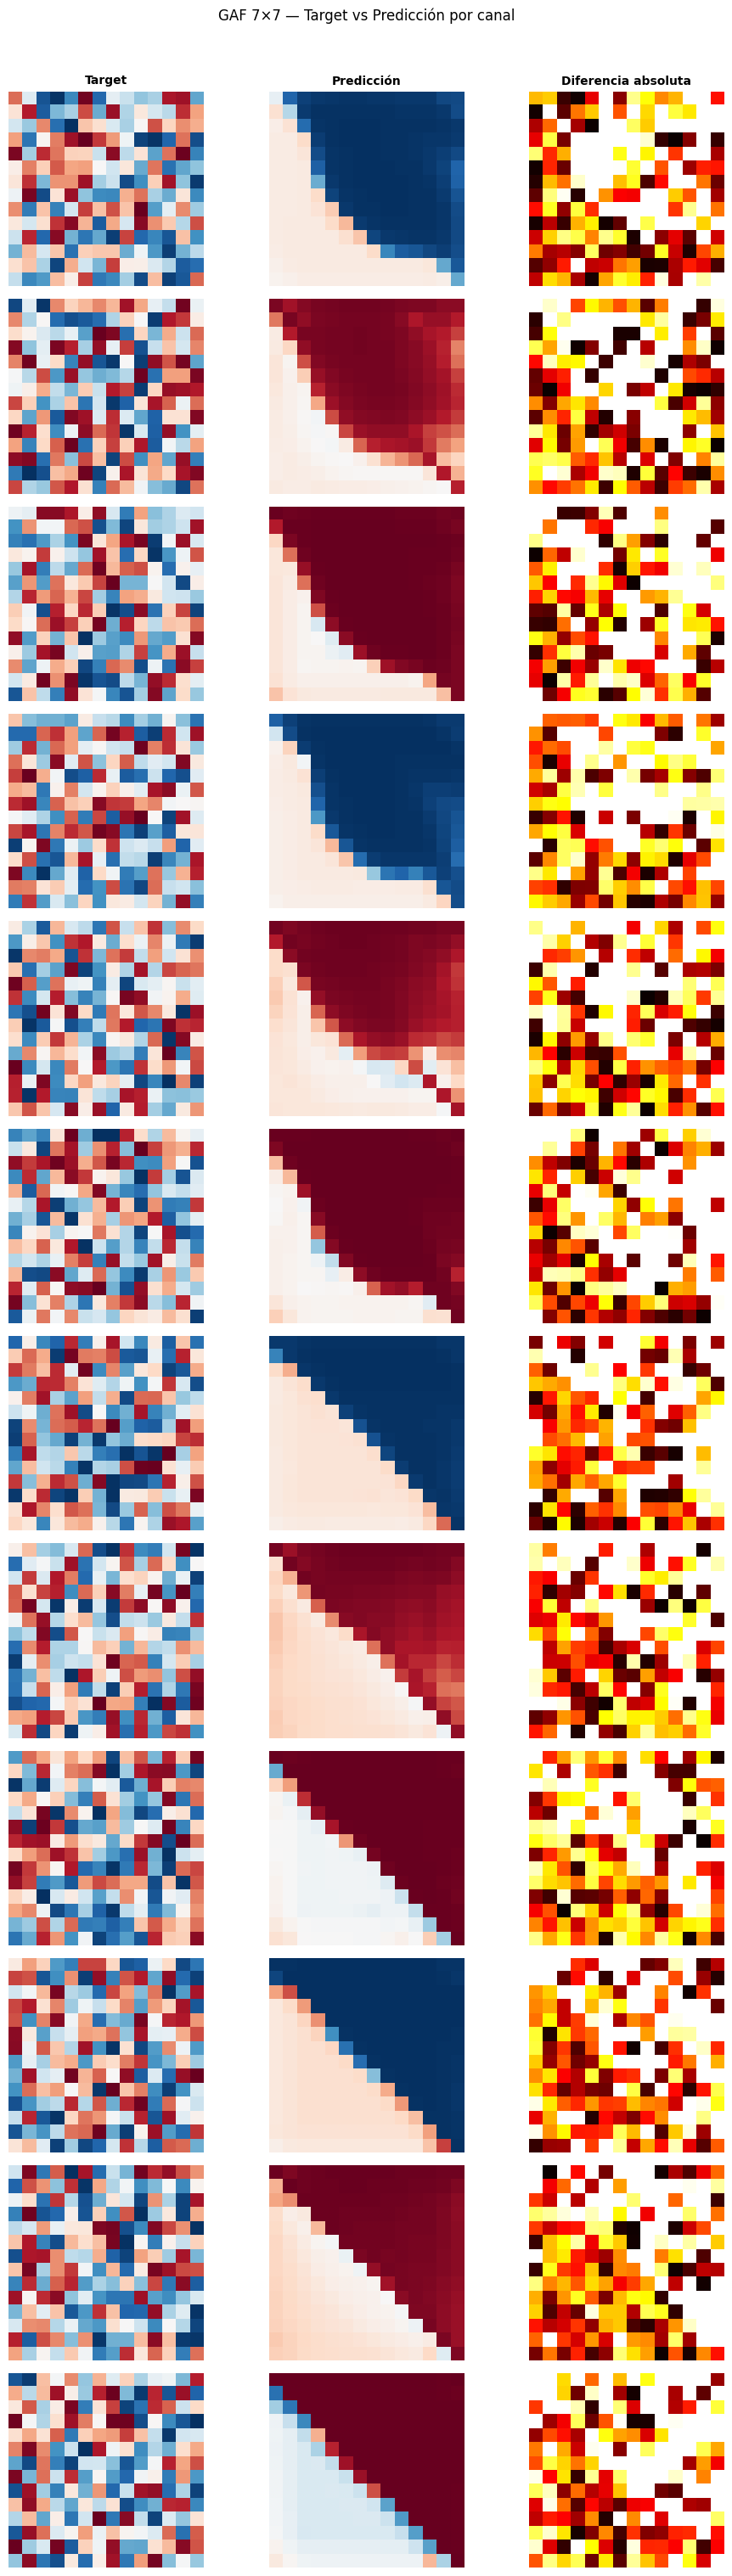

Guardado en /app/outputs/visualizations/fase6_gaf_comparison.png


In [22]:
def plot_gaf_comparison(targets, predictions, n_samples=4, channel_names=None):
    """
    Para cada muestra muestra 4 subplots por canal:
        Target | Predicción | Diferencia absoluta
    """
    if channel_names is None:
        channel_names = ['Ventas', 'Stock', 'Precio']

    n_channels = targets.shape[-1]
    n_samples  = min(n_samples, len(targets))

    fig, axes = plt.subplots(
        n_samples * n_channels, 3,
        figsize=(10, n_samples * n_channels * 2.5),
    )
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Target', 'Predicción', 'Diferencia absoluta']

    for s in range(n_samples):
        for c in range(n_channels):
            row = s * n_channels + c
            target_ch = targets[s, :, :, c]
            pred_ch   = predictions[s, :, :, c]
            diff_ch   = np.abs(target_ch - pred_ch)

            vmin, vmax = -1, 1

            axes[row, 0].imshow(target_ch, cmap='RdBu_r', vmin=vmin, vmax=vmax)
            axes[row, 1].imshow(pred_ch,   cmap='RdBu_r', vmin=vmin, vmax=vmax)
            im = axes[row, 2].imshow(diff_ch, cmap='hot',   vmin=0,    vmax=1)

            axes[row, 0].set_ylabel(f'Muestra {s+1}\n{channel_names[c]}', fontsize=8)
            for ax in axes[row]:
                ax.axis('off')

            if row == 0:
                for ax, title in zip(axes[row], col_titles):
                    ax.set_title(title, fontsize=10, fontweight='bold')

    plt.suptitle('GAF 7×7 — Target vs Predicción por canal', fontsize=12, y=1.01)
    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_gaf_comparison.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')

plot_gaf_comparison(targets, predictions, n_samples=4)

## 4. Diagonal: valores predichos vs reales

La diagonal del GAF es la serie de tiempo original desnormalizada.
Aquí comparamos los 7 valores diagonales predichos vs los reales.

In [23]:
def extract_diagonal(gaf_batch: np.ndarray) -> np.ndarray:
    """
    Extrae la diagonal principal de cada imagen GAF en el batch.
    Input:  (batch, 7, 7, channels)
    Output: (batch, 7, channels)
    """
    batch, h, w, c = gaf_batch.shape
    assert h == w, 'La imagen GAF debe ser cuadrada'
    diags = np.stack([np.diagonal(gaf_batch[b], axis1=0, axis2=1) for b in range(batch)])
    # np.diagonal devuelve (c, h) → transponer a (h, c)
    return diags.transpose(0, 2, 1)  # (batch, 7, channels)

diag_target = extract_diagonal(targets)
diag_pred   = extract_diagonal(predictions)

print(f'Diagonal target shape : {diag_target.shape}  (batch, 7 días, 3 canales)')
print(f'Diagonal pred shape   : {diag_pred.shape}')

Diagonal target shape : (32, 14, 3)  (batch, 7 días, 3 canales)
Diagonal pred shape   : (32, 14, 3)


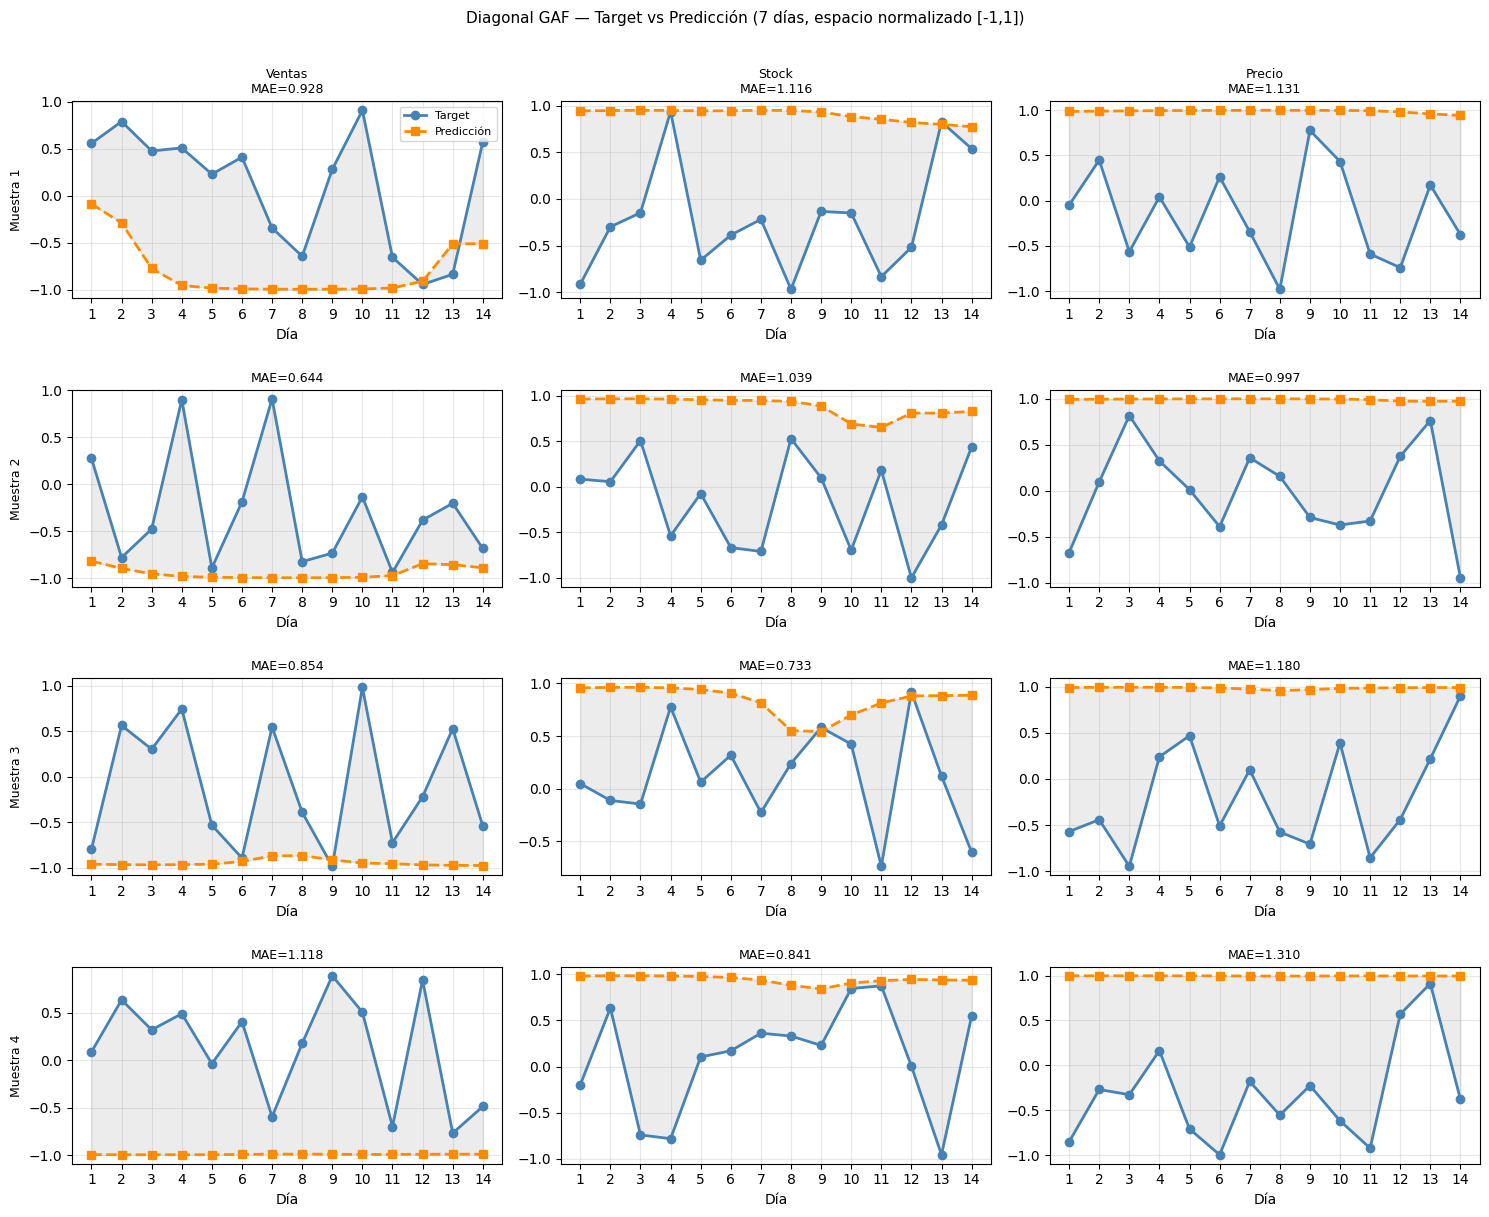

Guardado en /app/outputs/visualizations/fase6_diagonal_forecast.png

Nota: valores en espacio normalizado [-1, 1].
En Fase 8 con datos reales, aplicar invert_diagonal() de gaf/transform.py
para recuperar unidades/stock/precio reales.


In [24]:
def plot_diagonal_forecast(diag_target, diag_pred, n_samples=4, channel_names=None):
    if channel_names is None:
        channel_names = ['Ventas', 'Stock', 'Precio']

    n_channels = diag_target.shape[-1]
    n_samples  = min(n_samples, len(diag_target))
    days       = np.arange(1, diag_target.shape[1] + 1)

    fig, axes = plt.subplots(
        n_samples, n_channels,
        figsize=(5 * n_channels, 3 * n_samples),
        sharey=False,
    )
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for s in range(n_samples):
        for c in range(n_channels):
            ax = axes[s, c]
            ax.plot(days, diag_target[s, :, c], 'o-', color='steelblue',  label='Target',     linewidth=2)
            ax.plot(days, diag_pred[s,   :, c], 's--',color='darkorange', label='Predicción', linewidth=2)
            ax.fill_between(
                days,
                diag_target[s, :, c],
                diag_pred[s,   :, c],
                alpha=0.15, color='gray',
            )
            ax.set_xticks(days)
            ax.set_xlabel('Día')
            ax.grid(alpha=0.3)
            if s == 0:
                ax.set_title(channel_names[c], fontweight='bold')
            if c == 0:
                ax.set_ylabel(f'Muestra {s+1}', fontsize=9)
            if s == 0 and c == 0:
                ax.legend(fontsize=8)

            # MAE por muestra/canal
            mae = np.mean(np.abs(diag_target[s, :, c] - diag_pred[s, :, c]))
            ax.set_title(f'{channel_names[c] if s == 0 else ""}\nMAE={mae:.3f}', fontsize=9)

    plt.suptitle('Diagonal GAF — Target vs Predicción (7 días, espacio normalizado [-1,1])',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    path = str(VISUALIZATIONS / 'fase6_diagonal_forecast.png')
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado en {path}')
    print()
    print('Nota: valores en espacio normalizado [-1, 1].')
    print('En Fase 8 con datos reales, aplicar invert_diagonal() de gaf/transform.py')
    print('para recuperar unidades/stock/precio reales.')

plot_diagonal_forecast(diag_target, diag_pred, n_samples=4)

## 5. Métricas globales sobre el batch de validación

In [25]:
# MAE, RMSE, MAPE sobre la diagonal (todos los canales)
t = diag_target  # (batch, 7, 3)
p = diag_pred    # (batch, 7, 3)

mae  = np.mean(np.abs(t - p))
rmse = np.sqrt(np.mean((t - p) ** 2))

# MAPE: evitar división por cero
mask = np.abs(t) > 0.01
mape = np.mean(np.abs((t[mask] - p[mask]) / t[mask])) * 100 if mask.any() else float('nan')

# SSIM sobre imágenes completas
t_01 = (targets.astype('float32') + 1) / 2
p_01 = (predictions.astype('float32') + 1) / 2
ssim_vals = [
    tf.image.ssim(
        t_01[i:i+1], p_01[i:i+1],
        max_val=1.0, filter_size=3, filter_sigma=0.5
    ).numpy()[0]
    for i in range(len(targets))
]
ssim_mean = np.mean(ssim_vals)

print('══════════════════════════════════════════════')
print('  Métricas globales — batch de validación')
print('══════════════════════════════════════════════')
print(f'  MAE  (diagonal, norm.) : {mae:.4f}')
print(f'  RMSE (diagonal, norm.) : {rmse:.4f}')
print(f'  MAPE (diagonal, norm.) : {mape:.1f}%' if not np.isnan(mape) else '  MAPE : N/A (valores ~0)')
print(f'  SSIM (imagen 7×7)      : {ssim_mean:.4f}')
print('══════════════════════════════════════════════')
if USE_SYNTHETIC:
    print()
    print('  ⚠️  Datos sintéticos — métricas sin valor de referencia')
    print('  Con datos reales el objetivo es SSIM val > 0.7')

══════════════════════════════════════════════
  Métricas globales — batch de validación
══════════════════════════════════════════════
  MAE  (diagonal, norm.) : 0.9351
  RMSE (diagonal, norm.) : 1.0944
  MAPE (diagonal, norm.) : 425.8%
  SSIM (imagen 7×7)      : 0.0185
══════════════════════════════════════════════

  ⚠️  Datos sintéticos — métricas sin valor de referencia
  Con datos reales el objetivo es SSIM val > 0.7


## Resumen de validación

In [26]:
print('══════════════════════════════════════════════')
print('  FASE 6 — Resumen')
print('══════════════════════════════════════════════')
print(f'  Pipeline end-to-end     : ✅')
print(f'  Loss baja entre épocas  : ✅')
print(f'  Checkpoints guardados   : ✅')
print(f'  Visualizaciones GAF 7×7 : ✅')
print(f'  Diagonal extraída       : ✅')
print()
print('  Imágenes guardadas en outputs/visualizations/')
print('    - fase6_training_curves.png')
print('    - fase6_gaf_comparison.png')
print('    - fase6_diagonal_forecast.png')
print()
print('→ Siguiente: Fase 8 — conectar datos reales')
print('  Discutir en Claude.ai antes de implementar')

══════════════════════════════════════════════
  FASE 6 — Resumen
══════════════════════════════════════════════
  Pipeline end-to-end     : ✅
  Loss baja entre épocas  : ✅
  Checkpoints guardados   : ✅
  Visualizaciones GAF 7×7 : ✅
  Diagonal extraída       : ✅

  Imágenes guardadas en outputs/visualizations/
    - fase6_training_curves.png
    - fase6_gaf_comparison.png
    - fase6_diagonal_forecast.png

→ Siguiente: Fase 8 — conectar datos reales
  Discutir en Claude.ai antes de implementar
